# TMAP Quickstart Guide

This notebook walks through the complete TMAP pipeline:

1. **Encode** your data with MinHash
2. **Index** with LSHForest
3. **Layout** in 2D with force-directed algorithm
4. **Visualize** as interactive HTML

By the end, you'll have a working TMAP visualization!

## Setup

First, let's import the necessary modules and create some sample data.

In [17]:
import numpy as np

# TMAP imports
from tmap import LSHForest, MinHash
from tmap.layout import LayoutConfig, layout_from_lsh_forest
from tmap.visualization import TmapViz

print("TMAP imported successfully!")


TMAP imported successfully!


## Step 0: Create Sample Data

For this demo, we'll create synthetic binary fingerprints. In practice, you'd use molecular fingerprints, text features, or any binary/sparse data.

We'll create 3 clusters with different feature patterns so the tree shows clear structure.

In [18]:
np.random.seed(42)

n_samples = 30000
n_bits = 2048
n_clusters = 3

# Create clustered data - each cluster has different "active" bit ranges
fingerprints = np.zeros((n_samples, n_bits), dtype=np.uint8)
cluster_labels = []

for i in range(n_samples):
    cluster = i % n_clusters
    cluster_labels.append(f"Cluster_{cluster}")

    # Base features for this cluster (creates similarity within cluster)
    base_start = cluster * 500
    base_bits = np.random.choice(400, 50, replace=False) + base_start
    fingerprints[i, base_bits] = 1

    # Some random bits (adds variation)
    random_bits = np.random.choice(n_bits, 20, replace=False)
    fingerprints[i, random_bits] = 1

# Also create some continuous values for coloring
continuous_values = np.random.uniform(0, 100, n_samples)

print(f"Created {n_samples} fingerprints with {n_bits} bits each")
print(f"Average bits set: {fingerprints.sum(axis=1).mean():.1f}")
print(f"Clusters: {set(cluster_labels)}")


Created 30000 fingerprints with 2048 bits each
Average bits set: 69.5
Clusters: {'Cluster_1', 'Cluster_2', 'Cluster_0'}


## Step 1: MinHash Encoding

MinHash compresses your fingerprints into compact signatures while preserving Jaccard similarity.

**Key parameter:** `num_perm` controls the signature size (more = higher accuracy but slower)

In [19]:
# Create MinHash encoder
mh = MinHash(num_perm=128, seed=42)

# Encode fingerprints to signatures
# Use batch_from_binary_array for best performance
signatures = mh.batch_from_binary_array(fingerprints)

print(f"Original shape: {fingerprints.shape}")
print(f"Signature shape: {signatures.shape}")
print(f"Compression ratio: {fingerprints.nbytes / signatures.nbytes:.1f}x")


Original shape: (30000, 2048)
Signature shape: (30000, 128)
Compression ratio: 2.0x


## Step 2: Build LSH Forest Index

The LSH Forest enables fast approximate nearest neighbor queries.

**Key parameters:**
- `d`: Signature dimension (must match MinHash `num_perm`)
- `l`: Number of prefix trees (more = better recall, more memory)

In [20]:
# Create LSH Forest
lsh = LSHForest(d=128, l=64)

# Add all signatures
lsh.batch_add(signatures)

# Build the index (required before queries)
lsh.index()

print(f"Indexed {lsh.size} signatures")
print(f"Index is ready: {lsh.is_indexed}")


Indexed 30000 signatures
Index is ready: True


## Step 3: Compute Layout

This is where the magic happens! The layout algorithm:
1. Builds a k-nearest neighbor graph
2. Extracts the minimum spanning tree (MST)
3. Applies force-directed layout

**Key parameters:**
- `k`: Neighbors per point (higher = better connectivity)
- `kc`: Search quality multiplier (higher = better neighbors)
- `node_size`: Controls spacing (higher = more spread out)

In [21]:
# Configure layout
cfg = LayoutConfig()
cfg.k = 20          # 20 nearest neighbors
cfg.kc = 50         # Search 20*50 = 1000 candidates
cfg.node_size = 1/30  # Medium spread
cfg.fme_iterations = 500  # Layout iterations
cfg.deterministic = True  # Reproducible results
cfg.seed = 42

# Compute layout
x, y, s, t = layout_from_lsh_forest(lsh, cfg)

print("Layout computed!")
print(f"  Nodes: {len(x)}")
print(f"  Edges: {len(s)} (MST has n-1 edges for connected tree)")
print(f"  Coordinate range: x=[{x.min():.2f}, {x.max():.2f}], y=[{y.min():.2f}, {y.max():.2f}]")


Layout computed!
  Nodes: 30000
  Edges: 29999 (MST has n-1 edges for connected tree)
  Coordinate range: x=[-0.50, 0.50], y=[-0.50, 0.50]


## Step 4: Create Visualization

Now let's create an interactive HTML visualization with:
- Categorical coloring by cluster
- Continuous coloring by value
- Tree edges from layout output
- Labels in tooltips

In [22]:
# Create visualizer
viz = TmapViz()
viz.title = "TMAP Quickstart Demo"
viz.background_color = "#FFFFFF"  # White background
viz.point_size = 4.0
viz.opacity = 0.85

# Set coordinates
viz.set_points(x, y)
viz.set_edges(s, t)
viz.set_edge_style(color="#111111", width=1.5, opacity=0.35)

# Add categorical coloring (clusters)
viz.add_color_layout(
    name="Cluster",
    values=cluster_labels,
    categorical=True,
    color="Set1"  # Colormap for categories
)

# Add continuous coloring (values)
viz.add_color_layout(
    name="Value",
    values=continuous_values.tolist(),
    categorical=False,
    color="viridis"  # Colormap for continuous
)

# Add labels for tooltips
viz.add_label("ID", [f"Point_{i}" for i in range(n_samples)])

print(f"Visualization configured with {viz.n_points} points")
print(f"Color layouts: {[l.name for l in viz.layouts]}")
print(f"Labels: {[l.name for l in viz.labels]}")


Visualization configured with 30000 points
Color layouts: ['Cluster', 'Value']
Labels: ['Cluster', 'Value', 'ID']


## Step 5: Save and View

Save the visualization to an HTML file. You can open it in any web browser!

In [23]:
# Save to HTML
output_path = viz.save("./")

print(f"\nVisualization saved to: {output_path}")
print("\nOpen in your browser and try:")
print("  - Pan: Click and drag")
print("  - Zoom: Mouse wheel")
print("  - Hover: See point details")
print("  - Dropdown: Change color scheme")



Visualization saved to: TMAP Quickstart Demo.html

Open in your browser and try:
  - Pan: Click and drag
  - Zoom: Mouse wheel
  - Hover: See point details
  - Dropdown: Change color scheme


## Bonus: Quick Matplotlib Preview

If you want a quick preview without opening the HTML file:

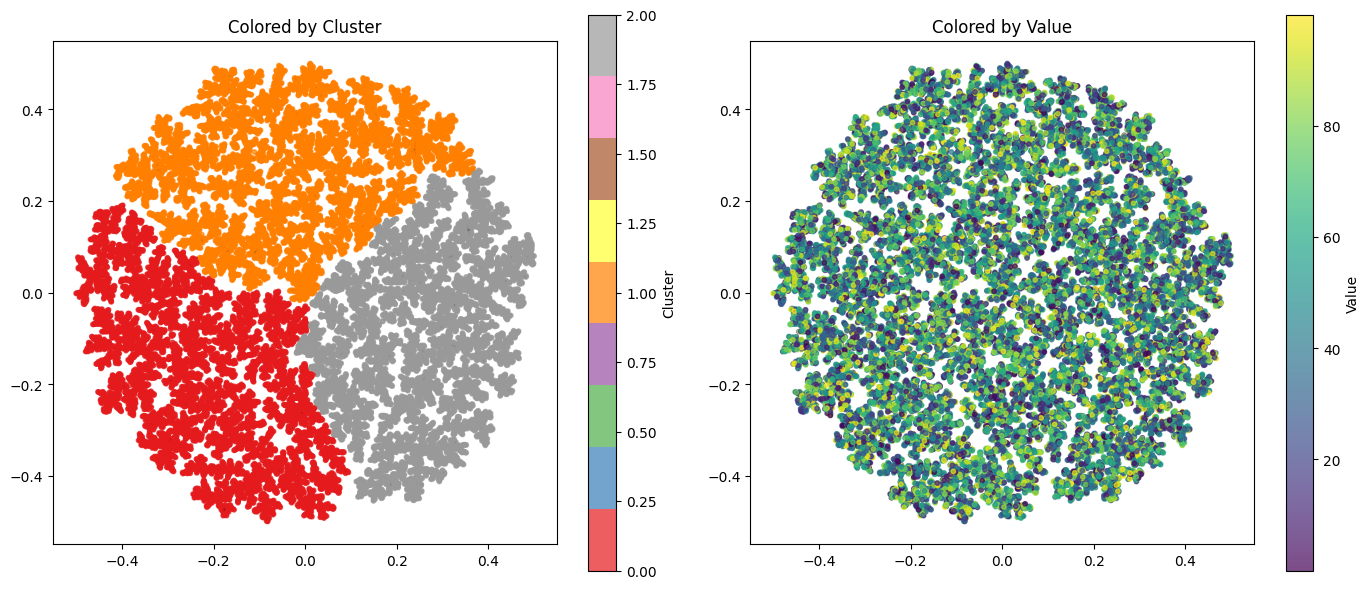


Note: The interactive HTML visualization has much better performance and features!


In [24]:
import matplotlib.pyplot as plt

# Create a simple scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Color by cluster
cluster_nums = [int(c.split('_')[1]) for c in cluster_labels]
scatter1 = axes[0].scatter(x, y, c=cluster_nums, cmap='Set1', s=10, alpha=0.7)
axes[0].set_title('Colored by Cluster')
axes[0].set_aspect('equal')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Right: Color by continuous value
scatter2 = axes[1].scatter(x, y, c=continuous_values, cmap='viridis', s=10, alpha=0.7)
axes[1].set_title('Colored by Value')
axes[1].set_aspect('equal')
plt.colorbar(scatter2, ax=axes[1], label='Value')

# Draw tree edges (optional - can be slow for large trees)
for i in range(min(len(s), 200)):  # Limit edges for speed
    axes[0].plot([x[s[i]], x[t[i]]], [y[s[i]], y[t[i]]], 'k-', alpha=0.1, linewidth=0.5)
    axes[1].plot([x[s[i]], x[t[i]]], [y[s[i]], y[t[i]]], 'k-', alpha=0.1, linewidth=0.5)

plt.tight_layout()
plt.show()

print("\nNote: The interactive HTML visualization has much better performance and features!")


## Summary

You've learned the complete TMAP pipeline:

```python
# 1. Encode
mh = MinHash(num_perm=128, seed=42)
signatures = mh.batch_from_binary_array(fingerprints)

# 2. Index
lsh = LSHForest(d=128, l=64)
lsh.batch_add(signatures)
lsh.index()

# 3. Layout
cfg = LayoutConfig()
cfg.k = 20
cfg.kc = 50
x, y, s, t = layout_from_lsh_forest(lsh, cfg)

# 4. Visualize
viz = TmapViz()
viz.set_points(x, y)
viz.set_edges(s, t)
viz.set_edge_style(color="#111111", width=1.5, opacity=0.35)
viz.add_color_layout("name", values, categorical=False)
viz.save("./")
```

## Next Steps

- See `02_minhash_deep_dive.ipynb` for encoding details
- See `03_tuning_parameters.ipynb` for parameter optimization
- Check the [documentation](../docs/) for full API reference